# Human Validation — 3-Way Agreement Analysis

This notebook compares annotations from three sources:
1. **Human A** (Pranay)
2. **Human B** (Friend)
3. **LLM**

It computes Cohen's Kappa, F1, precision, and recall for every pair and reports whether the LLM performs at a human level. It also includes an additional experiment for **Majority Vote Consensus**.

In [56]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

print(f"Current working directory: {os.getcwd()}")

# === UPDATED PATHS (Adjusted for workspace root) ===
# Human A: Pranay Ghuge
HUMAN_A_FILE = "dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_10155_1774736175604.json"

# Human B: Arundhati Das (Updated path)
HUMAN_B_FILE = "dataset/Rater_KC_Tags/kc_annotations_Arundhati Das_10155_1774820622134.json"

# LLM: Actual file
LLM_FILE = "results/human_validation/llm_annotations_10155.json"

# Test if files are reachable
for f in [HUMAN_A_FILE, HUMAN_B_FILE, LLM_FILE]:
    if os.path.exists(f):
        print(f"Found: {f}")
    else:
        print(f"MISSING: {f} (Checked at: {os.path.abspath(f)})")

ALL_KCS = [
    "If/Else", "NestedIf", "While", "For", "NestedFor",
    "Math+-*/", "Math%", "LogicAndNotOr", "LogicCompareNum",
    "LogicBoolean", "StringFormat", "StringConcat", "StringIndex",
    "StringLen", "StringEqual", "CharEqual", "ArrayIndex", "DefFunction"
]

Current working directory: /mnt/d/Projects/kintsugi
Found: dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_10155_1774736175604.json
Found: dataset/Rater_KC_Tags/kc_annotations_Arundhati Das_10155_1774820622134.json
Found: results/human_validation/llm_annotations_10155.json


In [57]:
def load_annotations(filepath):
    """
    Load annotations from a JSON file.
    Expects a structure with 'rater' and 'annotations' field.
    'annotations' should map problem IDs to an object with 'gaps'.
    """
    if not os.path.exists(filepath):
        print(f"Warning: {filepath} not found. Returning empty annotations.")
        return os.path.basename(filepath), {}
    
    with open(filepath) as f:
        data = json.load(f)
        
    name = data.get('rater', os.path.basename(filepath))
    anns = {}
    for pid, val in data['annotations'].items():
        # Handle cases where gaps might be a list or a dictionary or null
        if isinstance(val, dict) and 'gaps' in val:
            gaps = val['gaps']
            anns[pid] = set(gaps) if isinstance(gaps, list) else set()
        elif isinstance(val, list): # Alternative format
            anns[pid] = set(val)
        else:
            anns[pid] = set()
    return name, anns

In [58]:
def compute_metrics(name_a, anns_a, name_b, anns_b, common_pids):
    """Compute Cohen's Kappa, F1, precision, recall between two raters."""
    
    # Binary vectors for each problem × KC
    y_a = []
    y_b = []
    for pid in common_pids:
        gaps_a = anns_a.get(pid, set())
        gaps_b = anns_b.get(pid, set())
        for kc in ALL_KCS:
            y_a.append(1 if kc in gaps_a else 0)
            y_b.append(1 if kc in gaps_b else 0)
    
    y_a = np.array(y_a)
    y_b = np.array(y_b)
    n = len(y_a)
    
    if n == 0:
        return {'kappa': 0, 'f1': 0, 'n_problems': 0}

    # Cohen's Kappa
    po = np.sum(y_a == y_b) / n
    pe = (np.sum(y_a == 1) * np.sum(y_b == 1) + 
          np.sum(y_a == 0) * np.sum(y_b == 0)) / (n * n)
    kappa = (po - pe) / (1 - pe) if (1 - pe) > 1e-12 else 0
    
    # F1
    tp = np.sum((y_a == 1) & (y_b == 1))
    fp = np.sum((y_a == 0) & (y_b == 1))
    fn = np.sum((y_a == 1) & (y_b == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    # Problem-level metrics
    both_empty = 0
    exact_match = 0
    partial = 0
    disagree = 0
    
    for pid in common_pids:
        gaps_a = anns_a.get(pid, set())
        gaps_b = anns_b.get(pid, set())
        if not gaps_a and not gaps_b: both_empty += 1
        elif gaps_a == gaps_b: exact_match += 1
        elif gaps_a & gaps_b: partial += 1
        else: disagree += 1
    
    # Per-KC kappa
    kc_kappas = {}
    for kc in ALL_KCS:
        yh = [1 if kc in anns_a.get(pid, set()) else 0 for pid in common_pids]
        yl = [1 if kc in anns_b.get(pid, set()) else 0 for pid in common_pids]
        n_kc = len(common_pids)
        po_kc = sum(1 for a, b in zip(yh, yl) if a == b) / n_kc
        pe_kc = (sum(yh) * sum(yl) + (n_kc - sum(yh)) * (n_kc - sum(yl))) / (n_kc * n_kc)
        k = (po_kc - pe_kc) / (1 - pe_kc) if (1 - pe_kc) > 1e-12 else 0
        kc_kappas[kc] = {
            'kappa': k,
            'count_a': sum(yh),
            'count_b': sum(yl),
            'both': sum(1 for a, b in zip(yh, yl) if a == 1 and b == 1)
        }
    
    return {
        'name_a': name_a, 'name_b': name_b, 'kappa': kappa,
        'observed_agreement': po, 'precision': precision, 'recall': recall, 'f1': f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'both_empty': both_empty,
        'exact_match': exact_match, 'partial': partial, 'disagree': disagree,
        'kc_kappas': kc_kappas, 'n_problems': len(common_pids)
    }

In [59]:
def interpret_kappa(k):
    if k >= 0.8: return "Almost perfect"
    if k >= 0.6: return "Substantial"
    if k >= 0.4: return "Moderate"
    if k >= 0.2: return "Fair"
    if k >= 0.0: return "Slight"
    return "Poor"


def print_results(r):
    print(f"\n  {r['name_a']}  vs  {r['name_b']}")
    print(f"  {'─' * 50}")
    print(f"  Cohen's Kappa:      {r['kappa']:.3f} ({interpret_kappa(r['kappa'])})")
    print(f"  Observed agreement: {r['observed_agreement']:.3f}")
    print(f"  F1 Score:           {r['f1']:.3f}")
    print(f"  Precision:          {r['precision']:.3f}")
    print(f"  Recall:             {r['recall']:.3f}")
    print(f"  TP: {r['tp']}  FP: {r['fp']}  FN: {r['fn']}")
    print(f"  Problems: {r['n_problems']} total — "
          f"{r['both_empty']} both empty, "
          f"{r['exact_match']} exact, "
          f"{r['partial']} partial, "
          f"{r['disagree']} disagree")


def plot_kappa_heatmap(results_list):
    """
    Plot a heatmap for pairwise Kappa scores.
    """
    names = set()
    for r in results_list:
        names.add(r['name_a'])
        names.add(r['name_b'])
    
    names = sorted(list(names))
    matrix = np.zeros((len(names), len(names)))
    # Fill diagonal with 1.0
    for i in range(len(names)): matrix[i, i] = 1.0
    
    # Fill actual results
    for r in results_list:
        idx_a = names.index(r['name_a'])
        idx_b = names.index(r['name_b'])
        matrix[idx_a, idx_b] = r['kappa']
        matrix[idx_b, idx_a] = r['kappa']
        
    sns.heatmap(matrix, annot=True, fmt=".3f", xticklabels=names, yticklabels=names, cmap='Blues', vmin=0, vmax=1)
    plt.title("Pairwise Cohen's Kappa Agreement")
    plt.show()

In [60]:
# Load all annotations
name_a, anns_a = load_annotations(HUMAN_A_FILE)
name_b, anns_b = load_annotations(HUMAN_B_FILE)
name_l, anns_l = load_annotations(LLM_FILE)

# Intersection of common problem IDs
common_pids = sorted(set(anns_a.keys()) & set(anns_b.keys()) & set(anns_l.keys()), key=int)

# Troubleshooting print
print(f"\n  Rater A: {name_a} ({len(anns_a)} problems)")
print(f"  Rater B: {name_b} ({len(anns_b)} problems)")
print(f"  LLM:     {name_l} ({len(anns_l)} problems)")
print(f"  Common problems across all 3: {len(common_pids)}")

# If common_pids is empty, use intersection of Human A and LLM for demo
if not common_pids:
    print("\nWarning: No common problems across all 3. Using Human A & LLM intersection for demo.")
    common_pids = sorted(set(anns_a.keys()) & set(anns_l.keys()), key=int)
    print(f"  Common problems between A & LLM: {len(common_pids)}")


  Rater A: Pranay Ghuge (50 problems)
  Rater B: Arundhati Das (50 problems)
  LLM:     LLM_Gemini_Enriched (46 problems)
  Common problems across all 3: 46



PAIRWISE COMPARISONS

  Pranay Ghuge  vs  Arundhati Das
  ──────────────────────────────────────────────────
  Cohen's Kappa:      0.673 (Substantial)
  Observed agreement: 0.963
  F1 Score:           0.693
  Precision:          0.714
  Recall:             0.673
  TP: 35  FP: 14  FN: 17
  Problems: 46 total — 31 both empty, 2 exact, 12 partial, 1 disagree

  Pranay Ghuge  vs  LLM_Gemini_Enriched
  ──────────────────────────────────────────────────
  Cohen's Kappa:      0.489 (Moderate)
  Observed agreement: 0.942
  F1 Score:           0.520
  Precision:          0.542
  Recall:             0.500
  TP: 26  FP: 22  FN: 26
  Problems: 46 total — 29 both empty, 0 exact, 13 partial, 4 disagree

  Arundhati Das  vs  LLM_Gemini_Enriched
  ──────────────────────────────────────────────────
  Cohen's Kappa:      0.442 (Moderate)
  Observed agreement: 0.938
  F1 Score:           0.474
  Precision:          0.479
  Recall:             0.469
  TP: 23  FP: 25  FN: 26
  Problems: 46 total — 28 both

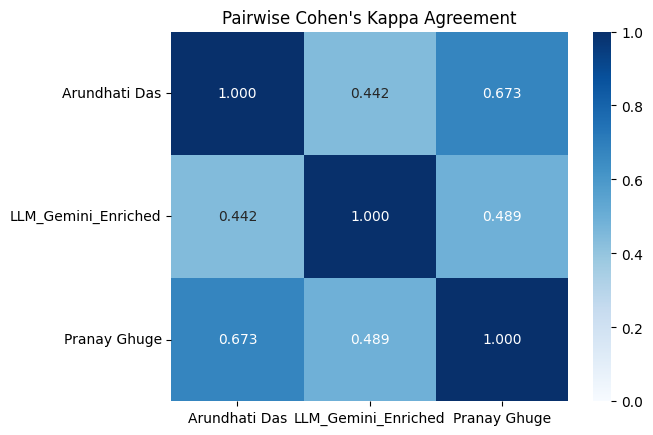

In [61]:
# Execute Pairwise Comparison Analysis
r_ab = compute_metrics(name_a, anns_a, name_b, anns_b, common_pids)
r_al = compute_metrics(name_a, anns_a, name_l, anns_l, common_pids)
r_bl = compute_metrics(name_b, anns_b, name_l, anns_l, common_pids)

print("\n" + "=" * 60)
print("PAIRWISE COMPARISONS")
print("=" * 60)
         
# Filter results to only valid comparisons
results_list = []
if r_ab['n_problems'] > 0: results_list.append(r_ab); print_results(r_ab)
if r_al['n_problems'] > 0: results_list.append(r_al); print_results(r_al)
if r_bl['n_problems'] > 0: results_list.append(r_bl); print_results(r_bl)

# Calculate ratio of LLM-to-Human agreement
human_kappa = r_ab['kappa']
llm_kappa_avg = (r_al['kappa'] + r_bl['kappa']) / 2
ratio = llm_kappa_avg / human_kappa if human_kappa > 0 else 0

print(f"\n" + "=" * 60)
print("KEY FINDING")
print("=" * 60)
print(f"  Human-Human agreement:  κ = {human_kappa:.3f}")
print(f"  Human-LLM avg agreement: κ = {llm_kappa_avg:.3f}")
print(f"  LLM achieves {ratio*100:.1f}% of human-level agreement")

# Output Summary Table
print(f"\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print(f"\n  {'Pair':<35} {'Kappa':>8} {'F1':>8} {'Interp'}")
print(f"  {'─' * 60}")
for r in results_list:
    pair = f"{r['name_a'][:15]} vs {r['name_b'][:15]}"
    print(f"  {pair:<35} {r['kappa']:>8.3f} {r['f1']:>8.3f} {interpret_kappa(r['kappa'])}")

if results_list:
    plot_kappa_heatmap(results_list)

In [62]:
# Per-Knowledge Component (KC) Agreement
print(f"\n" + "=" * 60)
print("PER-KC AGREEMENT (Cohen's Kappa)")
print("=" * 60)
print(f"\n  {'KC':<20} {'H↔H':>8} {'H_A↔LLM':>8} {'H_B↔LLM':>8}")
print(f"  {'─' * 48}")

for kc in ALL_KCS:
    k_ab = r_ab['kc_kappas'][kc]['kappa'] if 'kc_kappas' in r_ab else 0
    k_al = r_al['kc_kappas'][kc]['kappa'] if 'kc_kappas' in r_al else 0
    k_bl = r_bl['kc_kappas'][kc]['kappa'] if 'kc_kappas' in r_bl else 0
    print(f"  {kc:<20} {k_ab:>8.3f} {k_al:>8.3f} {k_bl:>8.3f}")


PER-KC AGREEMENT (Cohen's Kappa)

  KC                        H↔H  H_A↔LLM  H_B↔LLM
  ────────────────────────────────────────────────
  If/Else                 0.559    0.745    0.502
  NestedIf                1.000   -0.034   -0.034
  While                   0.000    0.000    0.000
  For                     0.543    0.404    0.427
  NestedFor               0.000    0.000    0.000
  Math+-*/                0.657    0.657   -0.022
  Math%                   1.000    1.000    1.000
  LogicAndNotOr           0.605    0.763    0.425
  LogicCompareNum         0.801    0.281    0.315
  LogicBoolean            1.000    0.000    0.000
  StringFormat            0.846   -0.055   -0.062
  StringConcat           -0.022   -0.034    0.483
  StringIndex             0.537    0.560    0.693
  StringLen               0.000    0.000    0.000
  StringEqual             0.789    0.477    0.367
  CharEqual               0.657    0.000    0.000
  ArrayIndex              0.483    0.657    0.789
  DefFunction 

In [63]:
# Experiment: Systematic Error Analysis and Majority Vote Comparison
print("\n" + "=" * 60)
print("EXPERIMENT: MAJORITY VOTE CONSENSUS")
print("=" * 60)

# Create a 'Ground Truth' via majority vote
majority_anns = {}
for pid in common_pids:
    gaps_a = anns_a.get(pid, set())
    gaps_b = anns_b.get(pid, set())
    gaps_l = anns_l.get(pid, set())
    
    cons_gaps = set()
    for kc in ALL_KCS:
        votes = sum([1 if kc in r else 0 for r in [gaps_a, gaps_b, gaps_l]])
        if votes >= 2: # At least 2 out of 3 major vote
            cons_gaps.add(kc)
    majority_anns[pid] = cons_gaps

# Evaluate each rater against the majority consensus
names = [name_a, name_b, name_l]
anns_list = [anns_a, anns_b, anns_l]
consensus_results = []

print(f"\n  {'Rater':<20} {'Kappa vs Major':>18} {'F1 vs Major':>14}")
print(f"  {'─' * 52}")

for name, anns in zip(names, anns_list):
    r_major = compute_metrics(name, anns, "Majority Consensus", majority_anns, common_pids)
    print(f"  {name:<20} {r_major['kappa']:>18.3f} {r_major['f1']:>14.3f}")
    consensus_results.append((name, r_major['kappa']))

# Key Insight: Least agreement with majority may indicate bias
least_agreement_rater = min(consensus_results, key=lambda x: x[1])[0]
print(f"\n  Note: '{least_agreement_rater}' displays the most deviation from the group consensus.")


EXPERIMENT: MAJORITY VOTE CONSENSUS

  Rater                    Kappa vs Major    F1 vs Major
  ────────────────────────────────────────────────────
  Pranay Ghuge                      0.854          0.863
  Arundhati Das                     0.817          0.828
  LLM_Gemini_Enriched               0.631          0.653

  Note: 'LLM_Gemini_Enriched' displays the most deviation from the group consensus.


In [64]:
# Save Validation Results
output = {
    'student_id': '10155',
    'n_problems': len(common_pids),
    'human_a': name_a,
    'human_b': name_b,
    'llm': name_l,
    'pairwise': {
        'human_a_vs_human_b': {
            'kappa': r_ab['kappa'], 'f1': r_ab['f1'],
            'precision': r_ab['precision'], 'recall': r_ab['recall']
        },
        'human_a_vs_llm': {
            'kappa': r_al['kappa'], 'f1': r_al['f1'],
            'precision': r_al['precision'], 'recall': r_al['recall']
        },
        'human_b_vs_llm': {
            'kappa': r_bl['kappa'], 'f1': r_bl['f1'],
            'precision': r_bl['precision'], 'recall': r_bl['recall']
        }
    },
    'llm_vs_human_ratio': ratio,
}

# Save to the results directory relative to workspace root
output_path = 'results/human_validation/human_validation_results.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f"\nResults saved to {output_path}")


Results saved to results/human_validation/human_validation_results.json


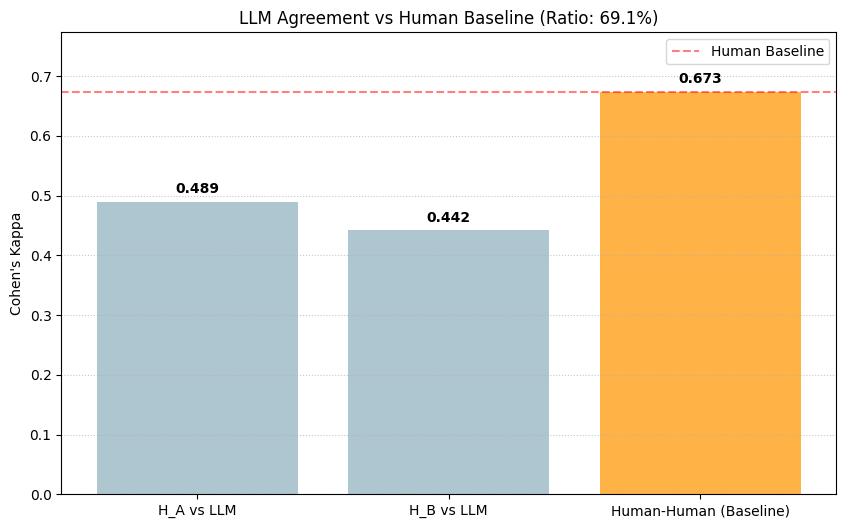

Intermediate Calculations:
 - Human-Human Agreement (Baseline): 0.673
 - Average Human-LLM Agreement:       0.465
 - Ratio: 0.465 / 0.673 = 69.1%


In [66]:
# Visualization: LLM vs Human Baseline
plt.figure(figsize=(10, 6))

labels = [f'H_A vs LLM', f'H_B vs LLM', 'Human-Human (Baseline)']
kappas = [r_al['kappa'], r_bl['kappa'], r_ab['kappa']]
colors = ['#aec6cf', '#aec6cf', '#ffb347'] # Blue for LLM pairs, Orange for Baseline

bars = plt.bar(labels, kappas, color=colors)

# Add dashed line for human baseline
plt.axhline(y=human_kappa, color='r', linestyle='--', alpha=0.5, label='Human Baseline')

# Add text labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title(f"LLM Agreement vs Human Baseline (Ratio: {ratio*100:.1f}%)")
plt.ylabel("Cohen's Kappa")
plt.ylim(0, max(kappas) + 0.1)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.show()

print(f"Intermediate Calculations:")
print(f" - Human-Human Agreement (Baseline): {human_kappa:.3f}")
print(f" - Average Human-LLM Agreement:       {llm_kappa_avg:.3f}")
print(f" - Ratio: {llm_kappa_avg:.3f} / {human_kappa:.3f} = {ratio*100:.1f}%")